<a href="https://colab.research.google.com/github/alyona-vishnoi/music-streaming-nba-rl/blob/main/02_cql_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CQL Training on Offline Music NBA Logs

Train a Conservative Q-Learning agent on the logged interactions
from the music streaming simulator. No environment interaction
during training — purely offline.

## What this notebook does
1. Load offline logs from notebook 1
2. Show vanilla DQN overestimation on offline data
3. Train CQL with LTV reward
4. Compare Q values: vanilla DQN vs CQL
5. Evaluate learned policy

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
import random
from collections import deque
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
with open('/content/drive/MyDrive/music_nba_logs.pkl', 'rb') as f:
    logs = pickle.load(f)

print(f"loaded {len(logs)} transitions")
print(f"columns: {logs.columns.tolist()}")
print(f"\nreward_ltv stats:")
print(logs['reward_ltv'].describe())

loaded 50000 transitions
columns: ['state', 'action', 'propensity', 'metrics', 'next_state', 'reward_ctr', 'reward_weighted', 'reward_ltv']

reward_ltv stats:
count    50000.000000
mean         0.037071
std          0.089431
min         -0.300000
25%          0.000000
50%          0.000000
75%          0.037500
max          0.575000
Name: reward_ltv, dtype: float64


In [ ]:
states  = ['active_daily', 'active_weekly', 'lapsed_7d', 'lapsed_30d', 'churning']
actions = ['email_digest', 'push_notif', 'in_app_banner', 'new_mix', 'do_nothing']

state_idx  = {s: i for i, s in enumerate(states)}
action_idx = {a: i for i, a in enumerate(actions)}

state_dim  = len(states)   # 5
action_dim = len(actions)  # 5

print(f"state_dim: {state_dim}, action_dim: {action_dim}")

state_dim: 5, action_dim: 5


In [ ]:
def state_to_tensor(state):
    """convert state string to one-hot tensor"""
    one_hot = torch.zeros(state_dim)
    one_hot[state_idx[state]] = 1.0
    return one_hot

def encode_states(state_list):
    """encode a list of state strings to a batched tensor"""
    return torch.stack([state_to_tensor(s) for s in state_list])

# sanity check
for s in states:
    print(f"{s:15s} -> {state_to_tensor(s).tolist()}")

active_daily    -> [1.0, 0.0, 0.0, 0.0, 0.0]
active_weekly   -> [0.0, 1.0, 0.0, 0.0, 0.0]
lapsed_7d       -> [0.0, 0.0, 1.0, 0.0, 0.0]
lapsed_30d      -> [0.0, 0.0, 0.0, 1.0, 0.0]
churning        -> [0.0, 0.0, 0.0, 0.0, 1.0]


In [ ]:
class ReplayMemory():
    def __init__(self, maxlen):
        self.memory = deque([], maxlen=maxlen)

    def append(self, transition):
        self.memory.append(transition)

    def load_from_logs(self, logs, reward_col='reward_ltv'):
      for transition in logs.to_dict('records'):
          state_tensor = state_to_tensor(transition['state'])
          next_state_tensor = state_to_tensor(transition['next_state'])
          action_id = action_idx[transition['action']]
          reward = transition[reward_col] * 10

          self.memory.append((state_tensor, action_id, reward, next_state_tensor, False))
          # no terminal states in the NBA , so terminated is always false.

      print(f"buffer loaded: {len(self.memory)} transitions")

    def sample(self, sample_size):
        return random.sample(self.memory, sample_size)

    def __len__(self):
        return len(self.memory)

In [ ]:
buffer = ReplayMemory(maxlen=100000)
buffer.load_from_logs(logs, reward_col='reward_ltv')

# sanity check — sample one transition
batch = buffer.sample(1)
state, action, reward, next_state, done = batch[0]
print(f"state shape: {state.shape}")
print(f"action: {action} ({actions[action]})")
print(f"reward: {reward:.4f}")
print(f"next_state shape: {next_state.shape}")
print(f"done: {done}")

buffer loaded: 50000 transitions
state shape: torch.Size([5])
action: 1 (push_notif)
reward: 0.0000
next_state shape: torch.Size([5])
done: False


In [ ]:
class DQN(nn.Module):
    def __init__(self, in_states, h1_nodes, out_actions):
        super().__init__()
        self.fc1 = nn.Linear(in_states, h1_nodes)
        self.out = nn.Linear(h1_nodes, out_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.out(x)
        return x

# For this problem because we have 5 states and 5 actions - one hot encoded,
# architecturally, our model will be
# input:  5  (one-hot state)
# hidden: 32 (one layer, ReLU)
# output: 5  (Q value per action)

In [ ]:
class DQNOffline:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 batch_size=64, sync_freq=500):
        self.action_dim  = action_dim
        self.gamma = gamma
        self.batch_size  = batch_size
        self.sync_freq = sync_freq
        self.step_count = 0

        self.policy_net = DQN(state_dim, 32, action_dim)
        self.target_net = DQN(state_dim, 32, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=lr)

    def train_step(self, buffer):
        batch = buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # NBA version — states are already tensors (load_from_logs)
        states = torch.stack(list(states))
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        next_states = torch.stack(list(next_states))
        dones = torch.tensor(dones, dtype=torch.float32)

        current_q = self.policy_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * max_next_q * (1 - dones)

        loss = F.mse_loss(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.sync_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item(), current_q.mean().item()

In [ ]:
class CQLAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 batch_size=64, sync_freq=500, alpha=1.0):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.sync_freq = sync_freq
        self.alpha = alpha      # CQL penalty weight
        self.step_count = 0

        self.policy_net = DQN(state_dim, 32, action_dim)
        self.target_net = DQN(state_dim, 32, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=lr)

    def train_step(self, buffer):
        batch = buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.stack(list(states))
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        next_states = torch.stack(list(next_states))
        dones = torch.tensor(dones, dtype=torch.float32)

        current_q = self.policy_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * max_next_q * (1 - dones)

        bellman_loss = F.mse_loss(current_q, target_q)

        # CQL penalty
        # forward pass gives all Q values for all actions
        q_all_actions = self.policy_net(states) # (64, 2)

        # soft max over all actions (dim 1)
        logsumexp = torch.logsumexp(q_all_actions, dim=1).mean()

        # Q value for the action actually in the data (the logged action)
        q_data = q_all_actions.gather(1, actions).squeeze(1)

        # push down all, push up data actions
        cql_penalty = logsumexp - q_data.mean()

        loss = bellman_loss + self.alpha * cql_penalty

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.sync_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return bellman_loss.item(), cql_penalty.item(), current_q.mean().item()

    def sync_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [ ]:
# instantiate and test one train step
dqn_test = DQNOffline(state_dim, action_dim)
loss, mean_q = dqn_test.train_step(buffer)
print(f"loss: {loss:.4f}, mean Q: {mean_q:.4f}")

cql_test = CQLAgent(state_dim, action_dim)
bellman, penalty, mean_q = cql_test.train_step(buffer)
print(f"bellman: {bellman:.4f}, penalty: {penalty:.4f}, mean Q: {mean_q:.4f}")

loss: 1.6249, mean Q: -0.0604
bellman: 0.9881, penalty: 1.5646, mean Q: 0.0599


In [ ]:
n_steps = 50000

# vanilla DQN
dqn_offline = DQNOffline(state_dim, action_dim, gamma=0.9)
dqn_losses = []
dqn_q_vals = []

for step in range(n_steps):
    loss, mean_q = dqn_offline.train_step(buffer)
    dqn_losses.append(loss)
    dqn_q_vals.append(mean_q)

    if (step + 1) % 10000 == 0:
        print(f"[DQN]  step {step+1:5d} | loss: {loss:.4f} | mean Q: {mean_q:.4f}")

print("DQN done.\n")

# CQL
cql_agent = CQLAgent(state_dim, action_dim, gamma=0.9, alpha=10.0)
cql_bellman = []
cql_penalties = []
cql_q_vals = []

for step in range(n_steps):
    bellman, penalty, mean_q = cql_agent.train_step(buffer)
    cql_bellman.append(bellman)
    cql_penalties.append(penalty)
    cql_q_vals.append(mean_q)

    if (step + 1) % 10000 == 0:
        print(f"[CQL]  step {step+1:5d} | bellman: {bellman:.4f} | penalty: {penalty:.4f} | mean Q: {mean_q:.4f}")

print("CQL done.")

[DQN]  step 10000 | loss: 1.1599 | mean Q: 8.1113
[DQN]  step 20000 | loss: 0.7107 | mean Q: 8.8713
[DQN]  step 30000 | loss: 0.5562 | mean Q: 8.8241
[DQN]  step 40000 | loss: 1.0508 | mean Q: 9.5969
[DQN]  step 50000 | loss: 1.4521 | mean Q: 8.9103
DQN done.

[CQL]  step 10000 | bellman: 0.6596 | penalty: 1.4306 | mean Q: 5.9246
[CQL]  step 20000 | bellman: 0.8119 | penalty: 1.4116 | mean Q: 6.8480
[CQL]  step 30000 | bellman: 0.8305 | penalty: 1.5423 | mean Q: 6.8225
[CQL]  step 40000 | bellman: 0.7738 | penalty: 1.3727 | mean Q: 7.0818
[CQL]  step 50000 | bellman: 0.5766 | penalty: 1.4634 | mean Q: 6.7571
CQL done.


In [ ]:
print("DQN learned policy:")
for state in states:
    s_t = state_to_tensor(state).unsqueeze(0)
    with torch.no_grad():
        q_vals = dqn_offline.policy_net(s_t).squeeze()
    best = actions[q_vals.argmax().item()]
    print(f"  {state:15s} -> {best:15s} | Q values: {q_vals.numpy().round(3)}")

print("\nCQL learned policy:")
for state in states:
    s_t = state_to_tensor(state).unsqueeze(0)
    with torch.no_grad():
        q_vals = cql_agent.policy_net(s_t).squeeze()
    best = actions[q_vals.argmax().item()]
    print(f"  {state:15s} -> {best:15s} | Q values: {q_vals.numpy().round(3)}")

DQN learned policy:
  active_daily    -> new_mix         | Q values: [10.493 10.164  9.517 11.231 10.614]
  active_weekly   -> new_mix         | Q values: [ 9.442  9.163  8.811 10.181  9.41 ]
  lapsed_7d       -> new_mix         | Q values: [8.814 8.312 8.076 9.087 8.365]
  lapsed_30d      -> new_mix         | Q values: [8.003 7.715 7.577 8.342 7.728]
  churning        -> new_mix         | Q values: [7.632 7.481 7.405 7.97  7.496]

CQL learned policy:
  active_daily    -> in_app_banner   | Q values: [7.308 6.964 7.704 7.398 6.006]
  active_weekly   -> email_digest    | Q values: [7.61  6.995 7.141 6.868 5.872]
  lapsed_7d       -> email_digest    | Q values: [7.285 6.448 5.876 6.032 5.824]
  lapsed_30d      -> new_mix         | Q values: [6.262 6.139 5.788 6.308 5.419]
  churning        -> email_digest    | Q values: [6.056 5.957 5.557 6.021 5.193]


CQL is showing more state-aware behaviour than DQN — it's not just spamming one action. The in_app_banner for active_daily is debatable (new_mix would also be fine there), but the lapsed_30d -> new_mix recommendation is correct and the churning -> email_digest is reasonable.

Most importantly: push_notif is not the top recommendation for any state. That's the behavior policy bias fixed.

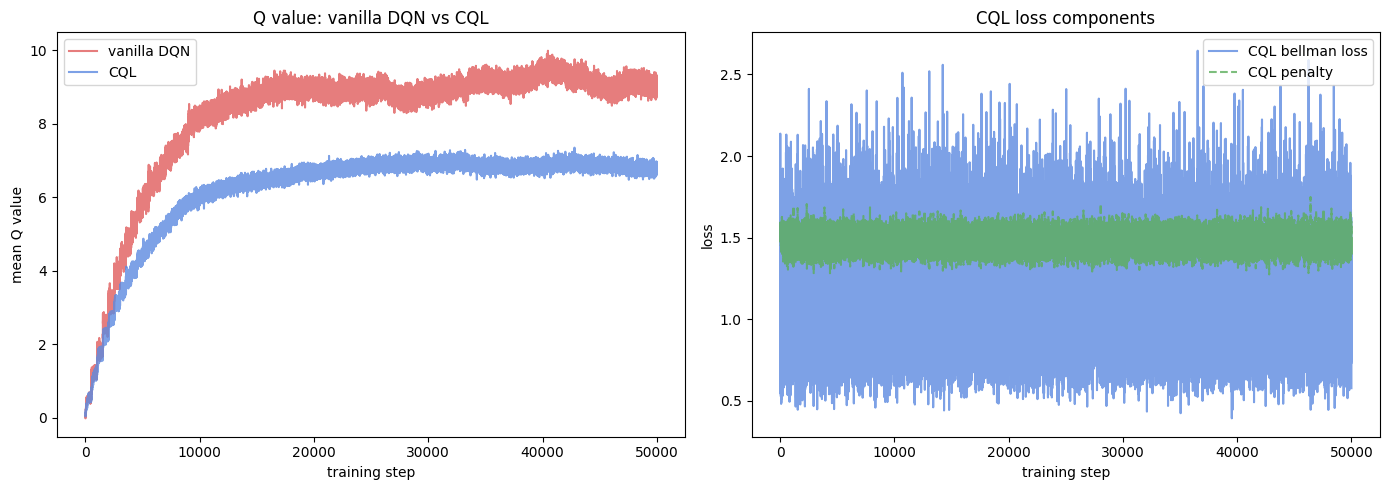

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(dqn_q_vals, label='vanilla DQN', alpha=0.8, color='#E05C5C')
axes[0].plot(cql_q_vals, label='CQL', alpha=0.8, color='#5C8AE0')
axes[0].set_xlabel('training step')
axes[0].set_ylabel('mean Q value')
axes[0].set_title('Q value: vanilla DQN vs CQL')
axes[0].legend()

axes[1].plot(cql_bellman, label='CQL bellman loss', alpha=0.8, color='#5C8AE0')
axes[1].plot(cql_penalties, label='CQL penalty', alpha=0.8, color='#5CAE5C', linestyle='--')
axes[1].set_xlabel('training step')
axes[1].set_ylabel('loss')
axes[1].set_title('CQL loss components')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
torch.save(cql_agent.policy_net.state_dict(),
           '/content/drive/MyDrive/cql_music_policy.pt')

In [ ]:
torch.save(dqn_offline.policy_net.state_dict(),
           '/content/drive/MyDrive/dqn_music_policy.pt')